# Optimization with JAXCad

JaxCAD is meant to be a fully differentiable CAD system. This means that you can compute gradients of any parameter in your model with respect to any loss function you define. This allows you to perform optimization tasks, such as shape optimization.

In [55]:
from jaxcad.sdf import Sphere, Translate, Union, volume, SDF
from jaxcad.geometry import Vector
from jaxcad.render import render_marching_cubes
from jaxcad.compiler import to_function, extract_parameters
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

An SDF object is differentiable with respect to any of its parameters, and you can use JAX's automatic differentiation to compute gradients. Here is a simple example of how to compute the gradient of a loss function with respect to some parameters in a JaxCAD model:

In [57]:
def double_sphere(p1 : jax.Array, p2 : jax.Array) -> SDF:
    sphere1 = Translate(Sphere(radius=1.0), offset=p1)
    sphere2 = Translate(Sphere(radius=1.0), offset=p2)
    return jax.jit(Union(
        sphere1,
        sphere2
    ))

In [60]:
def loss(p1 : jax.Array, p2 : jax.Array) -> jax.Array:
    return volume(double_sphere(p1, p2))

In [62]:
p1 = jnp.array([0.0, 0.0, 0.0])
p2 = jnp.array([1.0, 0.0, 0.0])

grad = jax.value_and_grad(loss, argnums=(0,1))
value, grads = grad(p1, p2)
print("Loss value:", value)
print("Gradient w.r.t p1:", grads[0])
print("Gradient w.r.t p2:", grads[1])


Loss value: 6.872672
Gradient w.r.t p1: [-1.8908089e+00  2.6822090e-07  5.8858257e-07]
Gradient w.r.t p2: [1.9764318e+00 8.1956387e-07 8.0093946e-07]


<Axes3D: title={'center': '3D Mesh (Marching Cubes)'}, xlabel='X', ylabel='Y', zlabel='Z'>

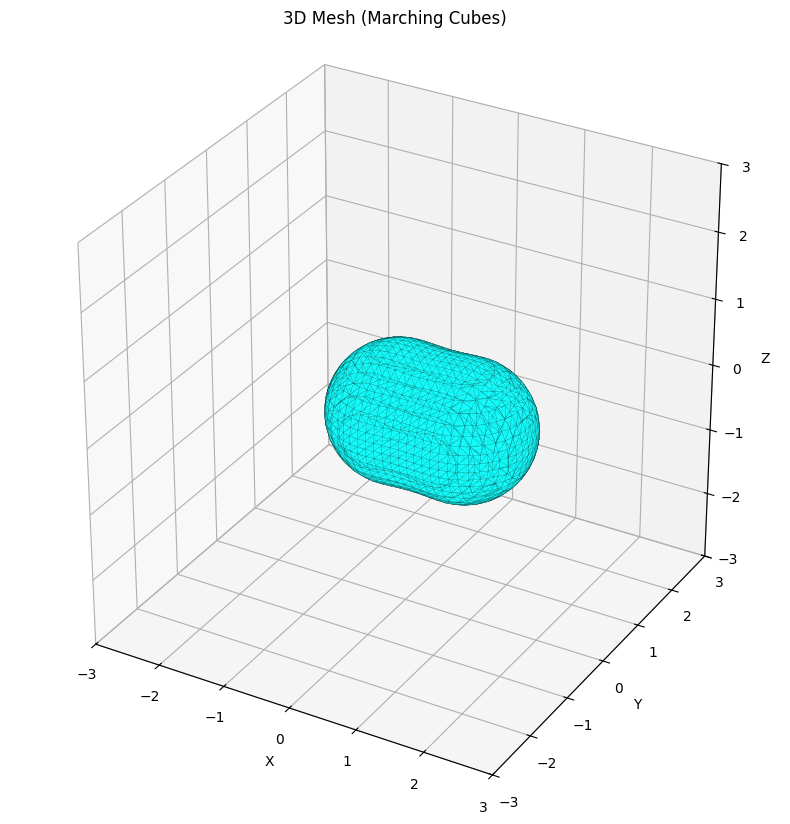

In [54]:
render_marching_cubes(double_sphere(p1, p2))

This is great, however how can we 

In [9]:
free_params, fixed_params = extract_parameters(scene)
scene_functional = jax.jit(to_function(scene))
scene_functional(jnp.array([0,0,0]), free_params, fixed_params)


Array(2.7416573, dtype=float32)

{'translate_1.offset': Vector(value=Array([1., 2., 3., 1.], dtype=float32), free=True, name='p1', bounds=None),
 'translate_3.offset': Vector(value=Array([4., 5., 6., 1.], dtype=float32), free=True, name='p2', bounds=None)}

JAXCad supports a variety of primitive shapes, transformations, and boolean operations. In this example, we will create a simple scene using some of the primitives and combine them with a union operation.

JAXCad also has utilites for rendering the resulting SDFs. In this example, we will use the marching cubes algorithm to render the scene as a mesh.

Text(0.5, 0, 'Z')

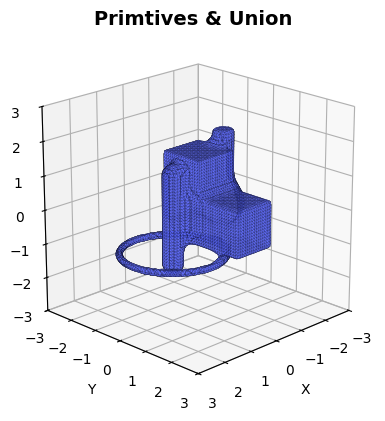

In [ ]:
fig = plt.figure(figsize=(16, 5))
ax1 = fig.add_subplot(131, projection='3d')

render_marching_cubes(
    scene,
    bounds=(-3, -3, -3),
    size=(6, 6, 6),
    resolution=70,
    ax=ax1,
    color="#5C69FF",
    alpha=0.8,
)
ax1.set_title('Primtives & Union', fontsize=14, fontweight='bold')
ax1.view_init(elev=20, azim=45)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

We can also apply some transformations on top of the scene SDFs.

Text(0.5, 0, 'Z')

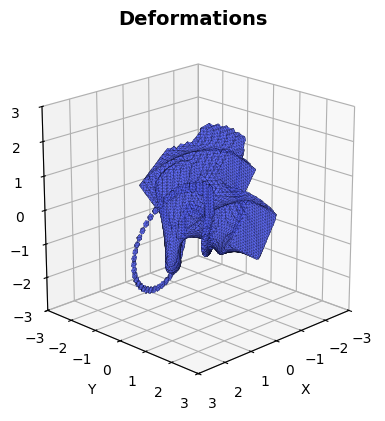

In [ ]:
from jaxcad.sdf.transforms.deformations import Twist

scene_ = Twist(scene, strength=1.0, axis=jnp.array([0.0, 1.0, 0.0]))

fig = plt.figure(figsize=(16, 5))
ax1 = fig.add_subplot(131, projection='3d')

render_marching_cubes(
    scene_,
    bounds=(-3, -3, -3),
    size=(6, 6, 6),
    resolution=70,
    ax=ax1,
    color="#5C69FF",
    alpha=0.8,
)
ax1.set_title('Deformations', fontsize=14, fontweight='bold')
ax1.view_init(elev=20, azim=45)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')